<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/breast_cancer_deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Breast cancer Deep learning

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)

In [2]:
breast_cancer_dataset = pd.read_csv("gbsg.csv")

In [3]:
print(breast_cancer_dataset)

     Unnamed: 0   pid  age  meno  size  grade  nodes   pgr    er  hormon  \
0             1   132   49     0    18      2      2     0     0       0   
1             2  1575   55     1    20      3     16     0     0       0   
2             3  1140   56     1    40      3      3     0     0       0   
3             4   769   45     0    25      3      1     0     4       0   
4             5   130   65     1    30      2      5     0    36       1   
..          ...   ...  ...   ...   ...    ...    ...   ...   ...     ...   
681         682   586   51     0    30      3      2  1152    38       1   
682         683  1273   64     1    26      2      2  1356  1144       1   
683         684  1525   57     1    35      3      1  1490   209       1   
684         685   736   44     0    21      2      3  1600    70       0   
685         686   894   80     1     7      2      7  2380   972       1   

     rfstime  status  
0       1838       0  
1        403       1  
2       1603      

In [4]:
breast_cancer_dataset.head()

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
0,1,132,49,0,18,2,2,0,0,0,1838,0
1,2,1575,55,1,20,3,16,0,0,0,403,1
2,3,1140,56,1,40,3,3,0,0,0,1603,0
3,4,769,45,0,25,3,1,0,4,0,177,0
4,5,130,65,1,30,2,5,0,36,1,1855,0


In [5]:
breast_cancer_dataset.tail()

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
681,682,586,51,0,30,3,2,1152,38,1,1760,0
682,683,1273,64,1,26,2,2,1356,1144,1,1152,0
683,684,1525,57,1,35,3,1,1490,209,1,1342,0
684,685,736,44,0,21,2,3,1600,70,0,629,0
685,686,894,80,1,7,2,7,2380,972,1,758,0


In [6]:
breast_cancer_dataset.shape

(686, 12)

In [7]:
breast_cancer_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 686 entries, 0 to 685
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  686 non-null    int64
 1   pid         686 non-null    int64
 2   age         686 non-null    int64
 3   meno        686 non-null    int64
 4   size        686 non-null    int64
 5   grade       686 non-null    int64
 6   nodes       686 non-null    int64
 7   pgr         686 non-null    int64
 8   er          686 non-null    int64
 9   hormon      686 non-null    int64
 10  rfstime     686 non-null    int64
 11  status      686 non-null    int64
dtypes: int64(12)
memory usage: 64.4 KB


In [8]:
breast_cancer_dataset.isnull().sum()

,0
Unnamed: 0,0
pid,0
age,0
meno,0
size,0
grade,0
nodes,0
pgr,0
er,0
hormon,0


In [9]:
breast_cancer_dataset.describe()

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime,status
count,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000,686.000000
mean,343.500000,966.061224,53.052478,0.577259,29.329446,2.116618,5.010204,109.995627,96.252187,0.358601,1124.489796,0.435860
std,198.175427,495.506249,10.120739,0.494355,14.296217,0.582808,5.475483,202.331552,153.083963,0.479940,642.791948,0.496231
min,1.000000,1.000000,21.000000,0.000000,3.000000,1.000000,1.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,172.250000,580.750000,46.000000,0.000000,20.000000,2.000000,1.000000,7.000000,8.000000,0.000000,567.750000,0.000000
50%,343.500000,1015.500000,53.000000,1.000000,25.000000,2.000000,3.000000,32.500000,36.000000,0.000000,1084.000000,0.000000
75%,514.750000,1340.500000,61.000000,1.000000,35.000000,2.000000,7.000000,131.750000,114.000000,1.000000,1684.750000,1.000000
max,686.000000,1819.000000,80.000000,1.000000,120.000000,3.000000,51.000000,2380.000000,1144.000000,1.000000,2659.000000,1.000000


In [10]:
breast_cancer_dataset.groupby('status').mean()

,Unnamed: 0,pid,age,meno,size,grade,nodes,pgr,er,hormon,rfstime
status,,,,,,,,,,,
0,381.819121,1045.410853,53.090439,0.558140,27.684755,2.049096,3.844961,140.490956,104.529716,0.392765,1376.919897
1,293.903010,863.357860,53.003344,0.602007,31.458194,2.204013,6.518395,70.525084,85.538462,0.314381,797.765886


In [11]:
X= breast_cancer_dataset.drop(columns=['status','Unnamed: 0'], axis=1)
Y = breast_cancer_dataset['status']

In [12]:
print(X)

      pid  age  meno  size  grade  nodes   pgr    er  hormon  rfstime
0     132   49     0    18      2      2     0     0       0     1838
1    1575   55     1    20      3     16     0     0       0      403
2    1140   56     1    40      3      3     0     0       0     1603
3     769   45     0    25      3      1     0     4       0      177
4     130   65     1    30      2      5     0    36       1     1855
..    ...  ...   ...   ...    ...    ...   ...   ...     ...      ...
681   586   51     0    30      3      2  1152    38       1     1760
682  1273   64     1    26      2      2  1356  1144       1     1152
683  1525   57     1    35      3      1  1490   209       1     1342
684   736   44     0    21      2      3  1600    70       0      629
685   894   80     1     7      2      7  2380   972       1      758

[686 rows x 10 columns]


In [13]:
print(Y)

0      0
1      1
2      0
3      0
4      0
      ..
681    0
682    0
683    0
684    0
685    0
Name: status, Length: 686, dtype: int64


In [14]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [15]:
print(X.shape, X_train.shape, X_test.shape)

(686, 10) (548, 10) (138, 10)


In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

In [18]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [19]:
model = keras.Sequential([
keras.layers.Flatten(input_shape=(10,)),
keras.layers.Dense(5,activation='relu'),
keras.layers.Dense(2,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.compile(optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy'])

In [21]:
history = model.fit(X_train_std, Y_train, validation_split=0.1, epochs=30)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5842 - loss: 0.7334 - val_accuracy: 0.4909 - val_loss: 0.7938
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6004 - loss: 0.7168 - val_accuracy: 0.5091 - val_loss: 0.7782
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5984 - loss: 0.7024 - val_accuracy: 0.5091 - val_loss: 0.7644
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5984 - loss: 0.6897 - val_accuracy: 0.5091 - val_loss: 0.7525
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6085 - loss: 0.6784 - val_accuracy: 0.5091 - val_loss: 0.7413
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6187 - loss: 0.6682 - val_accuracy: 0.5091 - val_loss: 0.7309
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6308 - loss: 0.6589 - val_accuracy: 0.5091 - val_loss: 0.7218
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6389 - loss: 0.6505 - val_accuracy: 0.5273 - val_loss

{'accuracy': [0.5841785073280334, 0.6004056930541992, 0.5983772873878479, 0.5983772873878479, 0.6085192561149597, 0.6186612844467163, 0.6308316588401794, 0.6389452219009399, 0.6531440019607544, 0.6653143763542175, 0.6754564046859741, 0.6734279990196228, 0.6774848103523254, 0.6774848103523254, 0.6774848103523254, 0.6835699677467346, 0.6896551847457886, 0.6977687478065491, 0.703853964805603, 0.7058823704719543, 0.7139959335327148, 0.7160243391990662, 0.7221095561981201, 0.7322515249252319, 0.7464503049850464, 0.7484787106513977, 0.7484787106513977, 0.7565922737121582, 0.7647058963775635, 0.7647058963775635], 'loss': [0.7334422469139099, 0.7168095111846924, 0.7023505568504333, 0.6896856427192688, 0.6783803105354309, 0.6681905388832092, 0.6589174270629883, 0.650549054145813, 0.6428496837615967, 0.6355320811271667, 0.6284564137458801, 0.6215546131134033, 0.6148189902305603, 0.6082305312156677, 0.6017398834228516, 0.595248281955719, 0.5886120200157166, 0.5820310115814209, 0.575628399848938, 

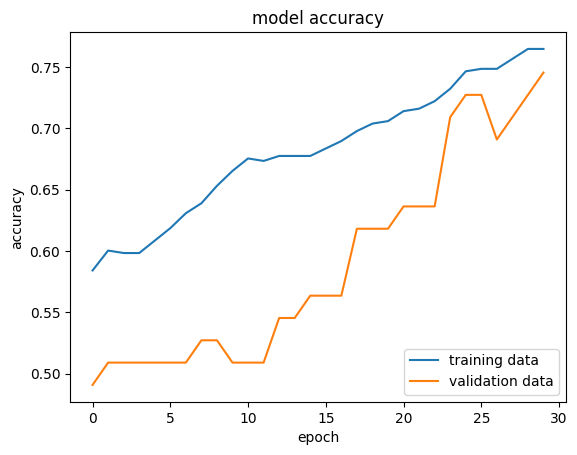

In [22]:
print(history.history)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')

plt.legend(['training data', 'validation data'], loc = 'lower right')

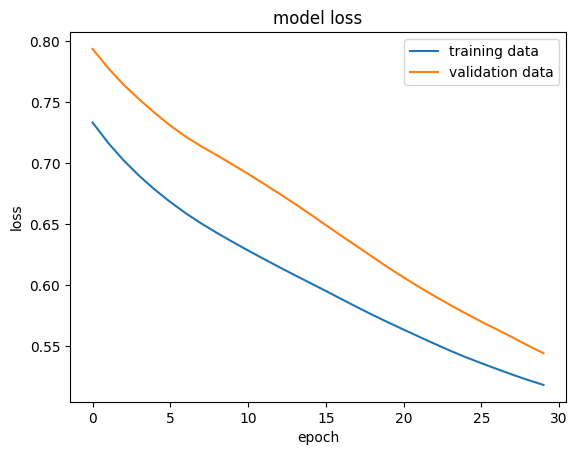

In [23]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training data', 'validation data'], loc = 'upper right')

In [24]:
loss, accuracy = model.evaluate(X_test_std, Y_test)
print(accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6884 - loss: 0.5602 
0.6884058117866516


In [25]:
print(X_test_std.shape)
print(X_test_std[0])

(138, 10)
[ 0.48840288 -1.43755272 -1.23035014  0.20378761 -0.21557883  0.82251797
 -0.52581694 -0.57323202 -0.79127287  1.31875957]


In [26]:
Y_pred = model.predict(X_test_std)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [27]:
print(Y_pred.shape)
print(Y_pred[0])

(138, 2)
[0.6256739 0.3875547]


In [28]:
print(X_test_std)

[[ 0.48840288 -1.43755272 -1.23035014 ... -0.57323202 -0.79127287
   1.31875957]
 [ 1.49590467 -1.7351647  -1.23035014 ... -0.62440178 -0.79127287
   0.08602535]
 [-0.01838877 -0.44551281 -1.23035014 ...  0.1431446   1.26378653
   0.56280805]
 ...
 [ 0.7053097   0.64573109 -1.23035014 ...  2.61848165 -0.79127287
   0.78708412]
 [ 0.29987638 -2.33038864 -1.23035014 ... -0.60521312 -0.79127287
  -1.4086257 ]
 [-0.56775091 -0.84232878 -1.23035014 ...  0.65484218 -0.79127287
   1.92885323]]


In [29]:
print(Y_pred)

[[0.6256739  0.3875547 ]
 [0.28250223 0.04285723]
 [0.59888566 0.24318567]
 [0.4549257  0.3747066 ]
 [0.17635955 0.38767502]
 [0.6114381  0.44206822]
 [0.51779306 0.45155725]
 [0.58193254 0.15219885]
 [0.54846156 0.4286377 ]
 [0.47390628 0.5167222 ]
 [0.47839543 0.48868397]
 [0.6331891  0.255888  ]
 [0.36101165 0.5800058 ]
 [0.45191926 0.52898425]
 [0.38116685 0.3880424 ]
 [0.6514818  0.41261163]
 [0.34496716 0.19392411]
 [0.28165805 0.5574136 ]
 [0.48252875 0.20298357]
 [0.3353978  0.47476345]
 [0.4796151  0.3594911 ]
 [0.5014154  0.5021206 ]
 [0.32803217 0.2001665 ]
 [0.16129555 0.4675431 ]
 [0.5434074  0.38970503]
 [0.38345665 0.22123677]
 [0.20427983 0.44357997]
 [0.327704   0.48511934]
 [0.31379712 0.4244983 ]
 [0.7602582  0.34463796]
 [0.40192497 0.30002275]
 [0.45712888 0.52748984]
 [0.19816296 0.5022404 ]
 [0.55331427 0.47385138]
 [0.4078354  0.24202417]
 [0.456671   0.14751245]
 [0.4312817  0.3965183 ]
 [0.51905817 0.19867639]
 [0.5158639  0.49397942]
 [0.16670473 0.10033131]


In [30]:
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0)

In [31]:
input_data = (1575,55,1,20,3,16,0,0,0,403)
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
input_data_std = scaler.transform(input_data_reshaped)
prediction = model.predict(input_data_std)
print(prediction)
prediction_label = [np.argmax(prediction)]
print(prediction_label)
#print(prediction_label[0])
if(prediction_label[0] == 0):
  print('The tumor is Malignant')
else:
  print('The tumor is Benign')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
[[0.36101162 0.5800058 ]]
[np.int64(1)]
The tumor is Benign


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
